In [8]:
%pip install scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from patsy import dmatrix
from scipy.stats import chi2
from scipy.stats import fisher_exact
from scipy.stats import binom
from scipy.optimize import brentq
from scipy.stats.contingency import odds_ratio
from statsmodels.stats.proportion import confint_proportions_2indep
from patsy import build_design_matrices
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

from pathlib import Path
import base64
import shlex
import subprocess
from io import StringIO

# Загрузка витрины и преобразование типов

In [10]:
PROJECT_ID = "sixth-tempo-506411-d9"

def run_bigquery(sql: str) -> pd.DataFrame:
    sql_b64 = base64.b64encode(sql.encode("utf-8")).decode("ascii")

    remote_command = (
        f"QUERY=$(echo {shlex.quote(sql_b64)} | base64 -d); "
        f"bq query "
        f"--project_id={PROJECT_ID} "
        f"--use_legacy_sql=false "
        f"--format=csv "
        f"--max_rows=1000000 "
        f'"$QUERY"'
    )

    result = subprocess.run(
        [
            "gcloud",
            "cloud-shell",
            "ssh",
            "--authorize-session",
            f"--command={remote_command}",
        ],
        capture_output=True,
        text=True,
        timeout=300,
    )

    if result.returncode != 0:
        print("STDOUT:")
        print(result.stdout)
        print("\nSTDERR:")
        print(result.stderr)
        raise RuntimeError("BigQuery query failed")

    return pd.read_csv(StringIO(result.stdout))

In [11]:
query = """
SELECT *
FROM `sixth-tempo-506411-d9.floodit_analytics.mart_user_early_journey`
"""

mart = run_bigquery(query)

mart.head()

,user_pseudo_id,cohort_date,platform,install_source,first_result_timestamp,first_result_outcome,is_activated,first_session_depth,retried_after_first_fail,same_day_return,is_d1_observable,is_d1_retained,is_d7_observable,is_d7_retained,has_iap,has_ad_reward,has_used_extra_steps,has_no_more_extra_steps,has_extra_steps_purchase
0,87331C2AC02608DB03191D5AA032B993,2018-08-26,IOS,iTunes,NaN,NaN,NaN,0,NaN,False,True,False,True,True,False,False,False,False,False
1,D5255DA563F26103F81E0A9701324260,2018-07-29,IOS,iTunes,NaN,NaN,NaN,0,NaN,False,True,False,True,False,False,False,False,False,False
2,B24B8B30B5849E3E9AB68263BD1A66EF,2018-08-26,ANDROID,com.android.vending,NaN,NaN,NaN,0,NaN,True,True,False,True,False,False,False,False,False,False
3,DBC07E3ECC7DD36D12BFEC862CD6B5A3,2018-07-29,ANDROID,com.android.vending,NaN,NaN,NaN,0,NaN,True,True,False,True,False,False,False,False,False,False
4,E2D541163121B35C342178FDA98CD3DC,2018-08-26,ANDROID,com.android.vending,NaN,NaN,NaN,0,NaN,True,True,False,True,False,False,False,False,False,False


In [12]:
mart.shape, mart["user_pseudo_id"].nunique(), mart.dtypes

((6068, 19),
 6068,
 user_pseudo_id                 str
 cohort_date                    str
 platform                       str
 install_source                 str
 first_result_timestamp         str
 first_result_outcome           str
 is_activated                object
 first_session_depth          int64
 retried_after_first_fail    object
 same_day_return               bool
 is_d1_observable              bool
 is_d1_retained              object
 is_d7_observable              bool
 is_d7_retained              object
 has_iap                       bool
 has_ad_reward                 bool
 has_used_extra_steps          bool
 has_no_more_extra_steps       bool
 has_extra_steps_purchase      bool
 dtype: object)

In [13]:
nullable_bool_cols = [
    "is_activated",
    "retried_after_first_fail",
    "is_d1_retained",
    "is_d7_retained",
]

for col in nullable_bool_cols:
    mart[col] = mart[col].astype("boolean")

In [14]:
mart["cohort_date"] = pd.to_datetime(mart["cohort_date"], errors="raise")

mart["first_result_timestamp"] = pd.to_datetime( mart["first_result_timestamp"], errors="coerce", utc=True)

In [15]:
mart.dtypes

user_pseudo_id                              str
cohort_date                      datetime64[us]
platform                                    str
install_source                              str
first_result_timestamp      datetime64[us, UTC]
first_result_outcome                        str
is_activated                            boolean
first_session_depth                       int64
retried_after_first_fail                boolean
same_day_return                            bool
is_d1_observable                           bool
is_d1_retained                          boolean
is_d7_observable                           bool
is_d7_retained                          boolean
has_iap                                    bool
has_ad_reward                              bool
has_used_extra_steps                       bool
has_no_more_extra_steps                    bool
has_extra_steps_purchase                   bool
dtype: object

In [16]:
new_users = len(mart)

users_with_first_result = mart["first_result_outcome"].notna().sum()
first_result_rate = users_with_first_result / new_users

activation_base = mart["first_result_outcome"].notna()
activated_users = mart.loc[activation_base, "is_activated"].sum()
activation_rate = activated_users / activation_base.sum()

first_fail_base = mart["first_result_outcome"].eq("fail")
users_with_first_fail = first_fail_base.sum()
retry_users = mart.loc[first_fail_base, "retried_after_first_fail"].sum()
retry_rate = retry_users / users_with_first_fail

same_day_return_users = mart["same_day_return"].sum()
same_day_return_rate = same_day_return_users / new_users

d1_observable_users = mart["is_d1_observable"].sum()
d1_retained_users = mart["is_d1_retained"].sum()
d1_retention = d1_retained_users / d1_observable_users

d7_observable_users = mart["is_d7_observable"].sum()
d7_retained_users = mart["is_d7_retained"].sum()
d7_retention = d7_retained_users / d7_observable_users

iap_users = mart["has_iap"].sum()
iap_rate = iap_users / new_users

In [17]:
baseline_metrics = pd.DataFrame({
    "metric": [
        "New users",
        "First result rate",
        "Activation rate",
        "Retry rate after first fail",
        "Same-day return rate",
        "D1 retention",
        "D7 retention",
        "IAP user rate",
    ],
    "value": [
        new_users,
        first_result_rate,
        activation_rate,
        retry_rate,
        same_day_return_rate,
        d1_retention,
        d7_retention,
        iap_rate,
    ],
})

baseline_metrics

,metric,value
0,New users,6068.000000
1,First result rate,0.638266
2,Activation rate,0.792925
3,Retry rate after first fail,0.693118
4,Same-day return rate,0.683256
5,D1 retention,0.206667
6,D7 retention,0.061560
7,IAP user rate,0.003626


# H1 - Activation и D1 retention

Проверим предположение о том, что ользователи, которые после первого результата продолжают играть в рамках первого периода взаимодействия с продуктом, чаще возвращаются в D1, чем пользователи, прекратившие игровое взаимодействие после первого результата.
При проверке использован односторонний z-test на пропорции, поскольку размер выборок допускает нормальную аппроксимацию, а атрибут is_active представлен булевым значением и подчиняется распределению бернулли:

- H₀: pₐctivated ≤ pₙon-activated
- H₁: pₐctivated > pₙon-activated
- α = 0.05

In [18]:
h1_data = mart[mart["first_result_outcome"].notna() & mart["is_d1_observable"].eq(True)]

len(h1_data)

3846

In [19]:
h1_groups = (
    h1_data
    .groupby("is_activated", as_index=False)
    .agg(
        users=("user_pseudo_id", "size"),
        d1_retained_users=("is_d1_retained", "sum"),
    )
)

h1_groups["d1_retention"] = (
    h1_groups["d1_retained_users"] / h1_groups["users"]
)

h1_groups

,is_activated,users,d1_retained_users,d1_retention
0,False,797,156,0.195734
1,True,3049,874,0.286651


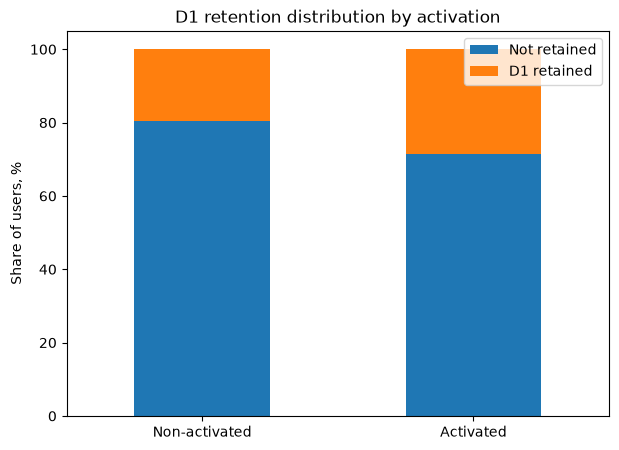

In [137]:
h1_distribution = (
    pd.crosstab(
        h1_data["is_activated"],
        h1_data["is_d1_retained"],
        normalize="index"
    ) * 100
)

h1_distribution = h1_distribution.rename(
    index={
        False: "Non-activated",
        True: "Activated"
    },
    columns={
        False: "Not retained",
        True: "D1 retained"
    }
)

h1_distribution[
    ["Not retained", "D1 retained"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.ylabel("Share of users, %")
plt.xlabel("")
plt.title("D1 retention distribution by activation")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

In [20]:
activated_users = h1_groups.loc[h1_groups["is_activated"].eq(True), "users"].iloc[0]
activated_retained = h1_groups.loc[h1_groups["is_activated"].eq(True), "d1_retained_users"].values[0]
non_activated_retained = h1_groups.loc[h1_groups["is_activated"].eq(False), "d1_retained_users"].values[0]

non_activated_users = h1_groups.loc[h1_groups["is_activated"].eq(False), "users"].values[0]
activated_retained, non_activated_retained, non_activated_users

(np.int64(874), np.int64(156), np.int64(797))

In [21]:

count = np.array([
    activated_retained,
    non_activated_retained,
])

nobs = np.array([
    activated_users,
    non_activated_users,
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="larger",
)

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.3e}")

z-statistic: 5.161
p-value: 1.229e-07


In [22]:
activated_rate = (
    activated_retained / activated_users
)

non_activated_rate = (
    non_activated_retained / non_activated_users
)

absolute_difference = (
    activated_rate - non_activated_rate
)

relative_lift = (
    absolute_difference / non_activated_rate
)

risk_ratio = (
    activated_rate / non_activated_rate
)

print(f"Activated D1: {activated_rate:.2%}")
print(f"Non-activated D1: {non_activated_rate:.2%}")
print(f"Difference: {absolute_difference * 100:.2f} п.п.")
print(f"Relative lift: {relative_lift:.2%}")
print(f"Risk ratio: {risk_ratio:.3f}")

Activated D1: 28.67%
Non-activated D1: 19.57%
Difference: 9.09 п.п.
Relative lift: 46.45%
Risk ratio: 1.464


In [23]:
ci_low, ci_high = confint_proportions_2indep(
    count1=activated_retained,
    nobs1=activated_users,
    count2=non_activated_retained,
    nobs2=non_activated_users,
    method="newcomb",
    compare="diff",
    alpha=0.05,
)

print(f"95% CI: [{ci_low * 100:.2f}; {ci_high * 100:.2f}] п.п.")

95% CI: [5.79; 12.17] п.п.


Весь доверительный интервал располагается правее нуля, на уровне значимости 0.05 активированные пользователи значимо чаще возвращаются на следующий день после первой результативной игры.

Рассмотрим сохранение тенденции по сегментам относительно атрибута platform:

In [24]:
h1_platform_groups = (
    h1_data
    .groupby(
        ["platform", "is_activated"],
        as_index=False
    )
    .agg(
        users=("user_pseudo_id", "size"),
        d1_retained_users=("is_d1_retained", "sum")
    )
)

h1_platform_groups["d1_retention"] = (h1_platform_groups["d1_retained_users"] / h1_platform_groups["users"])

h1_platform_groups

,platform,is_activated,users,d1_retained_users,d1_retention
0,ANDROID,False,359,84,0.233983
1,ANDROID,True,1872,565,0.301816
2,IOS,False,438,72,0.164384
3,IOS,True,1177,309,0.262532


In [25]:
def get_platform_metrics(df, platform):
    segment = df.loc[df["platform"].eq(platform)]

    activated = segment.loc[segment["is_activated"].eq(True)].iloc[0]

    non_activated = segment.loc[segment["is_activated"].eq(False)].iloc[0]

    activated_n = int(activated["users"])
    activated_r = int(activated["d1_retained_users"])

    non_activated_n = int(non_activated["users"])
    non_activated_r = int(non_activated["d1_retained_users"])

    activated_p = activated_r / activated_n
    non_activated_p = non_activated_r / non_activated_n

    return {
        "platform": platform,
        "activated_n": activated_n,
        "activated_r": activated_r,
        "activated_p": activated_p,
        "non_activated_n": non_activated_n,
        "non_activated_r": non_activated_r,
        "non_activated_p": non_activated_p,
    }

In [26]:
android = get_platform_metrics(h1_platform_groups,"ANDROID")

ios = get_platform_metrics(h1_platform_groups,"IOS")

Для объективного сравнения используем поправку Холма на множественное сравнение

In [27]:
h1_platform = pd.DataFrame([
    {
        "platform": name,
        "p_value": proportions_ztest(
            [m["activated_r"], m["non_activated_r"]],
            [m["activated_n"], m["non_activated_n"]],
            alternative="larger"
        )[1]
    }
    for name, m in {"ANDROID": android, "IOS": ios}.items()
])

h1_platform["significant_holm"], h1_platform["p_value_holm"], _, _ = multipletests(h1_platform["p_value"], alpha=0.05, method="holm")

h1_platform

,platform,p_value,significant_holm,p_value_holm
0,ANDROID,0.004769,True,0.004769
1,IOS,0.000018,True,0.000036


Отдельно рассморим вклад платформы в вероятность получить значение True D1_retention для отдельного user

In [28]:
h1_logit = h1_data[
    ["is_d1_retained", "is_activated", "platform"]
].dropna().copy()

h1_logit["is_d1_retained"] = h1_logit["is_d1_retained"].astype(int)
h1_logit["is_activated"] = h1_logit["is_activated"].astype(int)

model = smf.logit(
    "is_d1_retained ~ is_activated + C(platform)",
    data=h1_logit
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.576132
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         is_d1_retained   No. Observations:                 3846
Model:                          Logit   Df Residuals:                     3843
Method:                           MLE   Df Model:                            2
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                0.008496
Time:                        13:47:56   Log-Likelihood:                -2215.8
converged:                       True   LL-Null:                       -2234.8
Covariance Type:            nonrobust   LLR p-value:                 5.672e-09
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.2867      0.097    -13.203      0.000      -1.478      -1.096
C(platform)[T.IOS]    -0.2380      0.076     -3.146      0.002      -0.386      -0.090
is_activated           0.4639      0.099      4.704      0.000       0.271       0.657
======================================================================================
"""

Среди пользователей Android у активированных пользователей более высокий шанс возврата на следующий день. Среди неактивированных пользователей iOS более низкий шанс D1 retention. Результаты получены при условии одникого is_activated. Рассмотрим детальнее вклад platform, добавив в модель взаимосвязь с is_activated.

In [29]:
model_interaction = smf.logit(
    "is_d1_retained ~ is_activated * C(platform)",
    data=h1_logit
).fit()

model_interaction.summary()

Optimization terminated successfully.
         Current function value: 0.575931
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         is_d1_retained   No. Observations:                 3846
Model:                          Logit   Df Residuals:                     3842
Method:                           MLE   Df Model:                            3
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                0.008843
Time:                        13:47:56   Log-Likelihood:                -2215.0
converged:                       True   LL-Null:                       -2234.8
Covariance Type:            nonrobust   LLR p-value:                 1.344e-08
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.1860      0.125     -9.513      0.000      -1.430      -0.942
C(platform)[T.IOS]                 -0.4400      0.179     -2.454      0.014      -0.792      -0.089
is_activated                        0.3473      0.134      2.583      0.010       0.084       0.611
is_activated:C(platform)[T.IOS]     0.2458      0.198      1.243      0.214      -0.142       0.633
===================================================================================================
"""

Нет оснований утверждать, что связь activation с D1 retention статистически значимо различается между Android и iOS.

# H2 - результат первой игры и activation

Проверим действительно ли вероятность продолжения взаимодействия после первой завершенной игры различается в зависимости от результата(победа/проигрыш)
При проверке использован двусторонний z-test на пропорции, поскольку размер выборок допускает нормальную аппроксимацию, а атрибут is_active представлен булевым значением и подчиняется распределению бернулли:

- H₀: p_success = p_fail
- H₁: p_success ≠ p_fail
- α = 0.05

In [30]:
h2_data = mart[
    mart["first_result_outcome"].isin(["success", "fail"])
].copy()

len(h2_data)

3873

In [31]:
h2_groups = (
    h2_data
    .groupby("first_result_outcome", as_index=False)
    .agg(
        users=("user_pseudo_id", "size"),
        activated_users=("is_activated", "sum")
    )
)

h2_groups["activation_rate"] = (h2_groups["activated_users"]/ h2_groups["users"])

h2_groups

,first_result_outcome,users,activated_users,activation_rate
0,fail,1613,1212,0.751395
1,success,2260,1859,0.822566


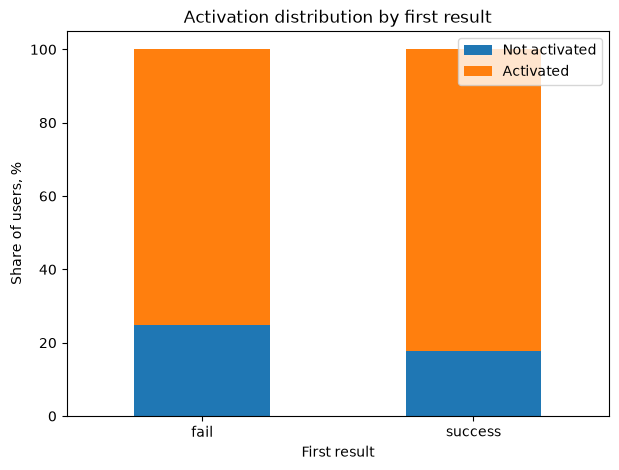

In [138]:
h2_distribution = (
    pd.crosstab(
        h2_data["first_result_outcome"],
        h2_data["is_activated"],
        normalize="index"
    ) * 100
)

h2_distribution = h2_distribution.rename(
    columns={
        False: "Not activated",
        True: "Activated"
    }
)

h2_distribution[
    ["Not activated", "Activated"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.ylabel("Share of users, %")
plt.xlabel("First result")
plt.title("Activation distribution by first result")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

In [32]:
success = h2_groups.loc[h2_groups["first_result_outcome"].eq("success")].iloc[0]

fail = h2_groups.loc[h2_groups["first_result_outcome"].eq("fail")].iloc[0]

success_users = int(success["users"])
success_activated = int(success["activated_users"])

fail_users = int(fail["users"])
fail_activated = int(fail["activated_users"])

In [33]:
pooled_p = (
    success_activated + fail_activated
) / (
    success_users + fail_users
)

expected_counts = np.array([
    success_users * pooled_p,
    success_users * (1 - pooled_p),
    fail_users * pooled_p,
    fail_users * (1 - pooled_p),
])

expected_counts

array([1792.0113607,  467.9886393, 1278.9886393,  334.0113607])

In [34]:
count = np.array([
    success_activated,
    fail_activated,
])

nobs = np.array([
    success_users,
    fail_users,
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided",
)

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.3e}")

z-statistic: 5.389
p-value: 7.102e-08


In [35]:
success_rate = success_activated / success_users
fail_rate = fail_activated / fail_users

absolute_difference = success_rate - fail_rate
risk_ratio = success_rate / fail_rate

print(f"Activation after success: {success_rate:.2%}")
print(f"Activation after fail: {fail_rate:.2%}")
print(f"Difference: {absolute_difference * 100:.2f} п.п.")
print(f"Risk ratio: {risk_ratio:.3f}")

Activation after success: 82.26%
Activation after fail: 75.14%
Difference: 7.12 п.п.
Risk ratio: 1.095


In [36]:
ci_low, ci_high = confint_proportions_2indep(
    count1=success_activated,
    nobs1=success_users,
    count2=fail_activated,
    nobs2=fail_users,
    method="newcomb",
    compare="diff",
    alpha=0.05,
)

print(f"95% CI: [{ci_low * 100:.2f}; {ci_high * 100:.2f}] п.п.")

95% CI: [4.50; 9.76] п.п.


На уровне значимости 0.05 вероятность activation статистически значимо различается в зависимости от результата первой результативной игровой попытки.
Если первая результативная игра завершена успешно, user с большей вероятностью продолжит взаимодействие с приложением в рамках той же аналитической сессии. 

Также установлено, что среди пользователей, чей первый наблюдаемый результат — `fail`, 69.31% начинают повторную попытку того же уровня/поля в рамках той же
аналитической сессии, наблюдения не тестируются и носят диагностический характер

# H3 - First session depth и D1

Проверим предположение о том, что число сыгранных пользователем результативных игр в течение первой сессии связано с вероятностью возвращения пользователя в D1.
`first_session_depth` — количественный дискретный признак, изучим распределение случайной величины для подбора критерия:

In [37]:
h3_data = mart[mart["is_d1_observable"].eq(True)]

h3_depth = (
    h3_data
    .groupby("first_session_depth", as_index=False)
    .agg(
        users=("user_pseudo_id", "size"),
        d1_retained_users=("is_d1_retained", "sum"),
    )
)

h3_depth["d1_retention"] = (h3_depth["d1_retained_users"] / h3_depth["users"])

h3_depth

,first_session_depth,users,d1_retained_users,d1_retention
0,0,5307,1071,0.201809
1,1,485,112,0.230928
2,2,114,30,0.263158
3,3,20,1,0.05
4,4,18,4,0.222222
5,5,13,3,0.230769
6,6,4,2,0.5
7,7,6,3,0.5
8,8,5,3,0.6
9,9,3,1,0.333333


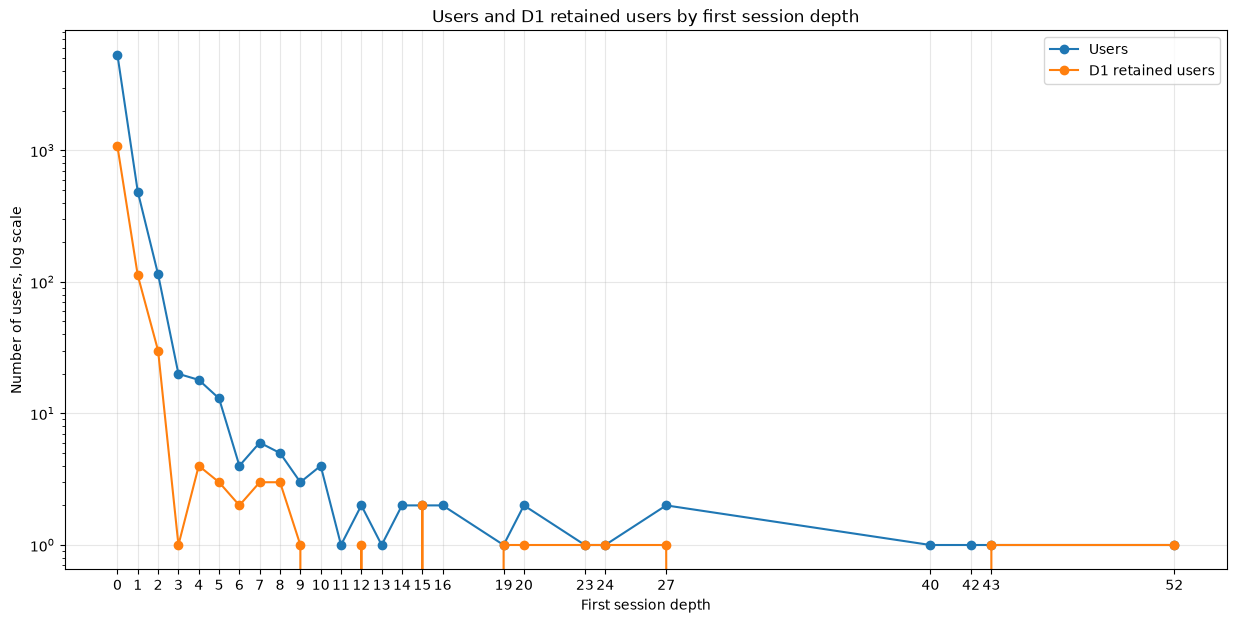

In [38]:
plt.figure(figsize=(15, 7))

plt.plot(
    h3_depth["first_session_depth"],
    h3_depth["users"],
    marker="o",
    label="Users"
)

plt.plot(
    h3_depth["first_session_depth"],
    h3_depth["d1_retained_users"],
    marker="o",
    label="D1 retained users"
)

plt.xlabel("First session depth")
plt.ylabel("Number of users, log scale")
plt.title("Users and D1 retained users by first session depth")

plt.xticks(h3_depth["first_session_depth"])
plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

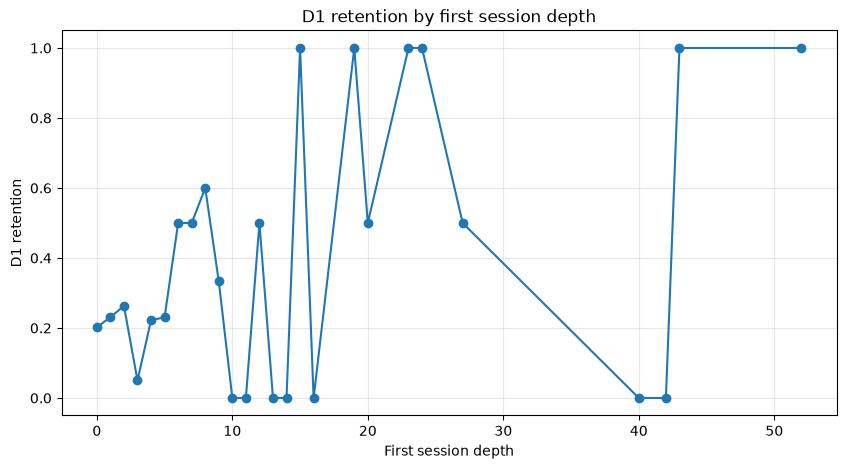

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    h3_depth["first_session_depth"],
    h3_depth["d1_retention"],
    marker="o"
)

plt.xlabel("First session depth")
plt.ylabel("D1 retention")
plt.title("D1 retention by first session depth")
plt.grid(alpha=0.3)

plt.show()

Воспользуемся эмпирической функцией распределения, построив график распределения относительно числа пользователей, вернувшихся в D1 и не вернувшихся в зависимости от глубины сессии.

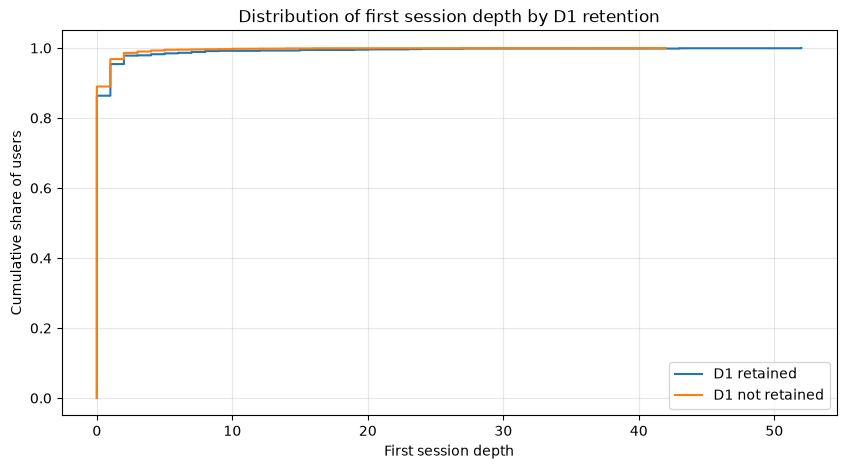

In [40]:
retained_depth = h3_data.loc[h3_data["is_d1_retained"].eq(True), "first_session_depth"]

not_retained_depth = h3_data.loc[h3_data["is_d1_retained"].eq(False), "first_session_depth"]


def ecdf(values):
    x = np.sort(values.to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


x_retained, y_retained = ecdf(retained_depth)
x_not_retained, y_not_retained = ecdf(not_retained_depth)

plt.figure(figsize=(10, 5))

plt.step(
    x_retained,
    y_retained,
    where="post",
    label="D1 retained"
)

plt.step(
    x_not_retained,
    y_not_retained,
    where="post",
    label="D1 not retained"
)

plt.xlabel("First session depth")
plt.ylabel("Cumulative share of users")
plt.title("Distribution of first session depth by D1 retention")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Для проверки гипотезы будем использовать критерий Манна-Уитни, поскольку данные не подчинаются нормальному закону распределения, распределение скошено вправо и имеет длинный разреженный хвост. Критерий позволит определить имеют ли вернувшиеся в D1 пользователи систематически более высокие значения first_session_depth, чем не вернувшиеся.

- H₀: распределение `first_session_depth` не различается между D1-retained и D1-not-retained пользователями.

- H₁: распределения `first_session_depth` различаются.

In [41]:
u_stat, p_value = mannwhitneyu(
    retained_depth,
    not_retained_depth,
    alternative="two-sided",
    method="asymptotic"
)

print(f"U-statistic: {u_stat:.0f}")
print(f"p-value: {p_value:.3e}")

U-statistic: 3031224
p-value: 7.901e-03


In [42]:
n_retained = len(retained_depth)
n_not_retained = len(not_retained_depth)

rank_biserial = (2 * u_stat / (n_retained * n_not_retained) - 1)

print(f"Rank-biserial correlation: {rank_biserial:.3f}")

Rank-biserial correlation: 0.027


In [43]:
retained_positive_depth = (retained_depth > 0).mean()
not_retained_positive_depth = (not_retained_depth > 0).mean()

print(f"D1 retained: {retained_positive_depth:.2%}")
print(f"D1 not retained: {not_retained_positive_depth:.2%}")
print(
    f"Difference: "
    f"{(retained_positive_depth - not_retained_positive_depth) * 100:.2f} п.п."
)

D1 retained: 13.63%
D1 not retained: 11.01%
Difference: 2.62 п.п.


На текущем уровне значимости видим статистически значимые различия, и отклоняем H₀, при этом размер эффекта равен 0.027.

Дополнительно рассмотрим существует ли зависимость D1 retained от depth session с помощью spline logistic regression

In [44]:
y = h3_data["is_d1_retained"].astype(int)

X_spline = dmatrix(
    "bs(first_session_depth, df=3, degree=3)",
    data=h3_data,
    return_type="dataframe"
)

# построим две модели full учитывает глубину первой сессии, null - нет
full_model = sm.GLM(
    y,
    X_spline,
    family=sm.families.Binomial()
).fit()

null_model = sm.GLM(
    y,
    np.ones((len(y), 1)),
    family=sm.families.Binomial()
).fit()

Сравним две модели, основываясь на:

- H₀: `first_session_depth` не связан на результат
- H₁: `first_session_depth` связан с результатом
- α = 0.05

При верной H₀ 2(LL_full ​− LL_null​) подчиняется распределению χ², df = 3

In [45]:
lr_stat = 2 * (full_model.llf - null_model.llf)

df_diff = (full_model.df_model - null_model.df_model)

p_value = chi2.sf(lr_stat, df_diff)

print(f"Likelihood-ratio statistic: {lr_stat:.3f}")
print(f"df: {df_diff:.0f}")
print(f"p-value: {p_value:.3e}")

Likelihood-ratio statistic: 13.640
df: 3
p-value: 3.438e-03


Likelihood-ratio statistic показывает, что с добавлением параметров модель стала лучше объяснять результат.
Сравнение выявило статистически значимые различия между full и null моделями, что позволяет отвергнуть H₀ о том, что глубина первой сессии не связана с результатом.

Построим прогноз для каждого значения depth от минимального до максимального, основываясь на spline-модель

In [46]:
depth_grid = pd.DataFrame({
    "first_session_depth": np.arange(
        h3_data["first_session_depth"].min(),
        h3_data["first_session_depth"].max() + 1
    )
})

X_pred = build_design_matrices(
    [X_spline.design_info],
    depth_grid
)[0]

prediction = full_model.get_prediction(X_pred).summary_frame(alpha=0.05)

depth_grid["predicted_d1"] = prediction["mean"].to_numpy()
depth_grid["ci_lower"] = prediction["mean_ci_lower"].to_numpy()
depth_grid["ci_upper"] = prediction["mean_ci_upper"].to_numpy()

depth_grid.head()

,first_session_depth,predicted_d1,ci_lower,ci_upper
0,0,0.202315,0.191969,0.213072
1,1,0.221532,0.204189,0.239904
2,2,0.240624,0.209384,0.274903
3,3,0.259400,0.214559,0.309915
4,4,0.277692,0.220355,0.343378


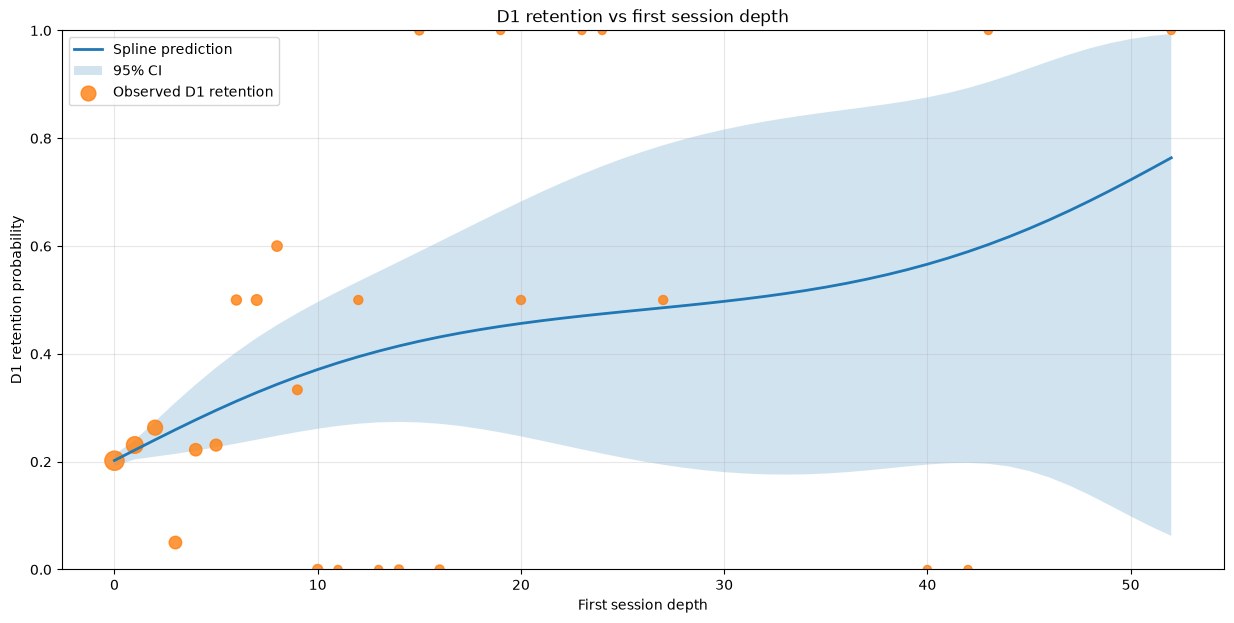

In [47]:
plt.figure(figsize=(15, 7))

# Предсказанная spline-моделью вероятность D1
plt.plot(
    depth_grid["first_session_depth"],
    depth_grid["predicted_d1"],
    linewidth=2,
    label="Spline prediction"
)

# 95% CI
plt.fill_between(
    depth_grid["first_session_depth"],
    depth_grid["ci_lower"],
    depth_grid["ci_upper"],
    alpha=0.2,
    label="95% CI"
)

# Фактический D1 retention для каждого depth
plt.scatter(
    h3_depth["first_session_depth"],
    h3_depth["d1_retention"],
    s=20 + 20 * np.log1p(h3_depth["users"]),
    alpha=0.8,
    label="Observed D1 retention"
)

plt.xlabel("First session depth")
plt.ylabel("D1 retention probability")
plt.title("D1 retention vs first session depth")

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

График позволяет заключить, что статистически значимая разница между моделями full и null, не была обусловлена только разреженным хвостом, поскольку в диапазоне от 0 до 2, в котором и содержатся почти все пользователи видна положительная динамика в сторону роста возвращения в D1 с увеличением `first_session_depth`

Тот же график, сосредоточенный в значениях `first_session_depth` от 0 до 20

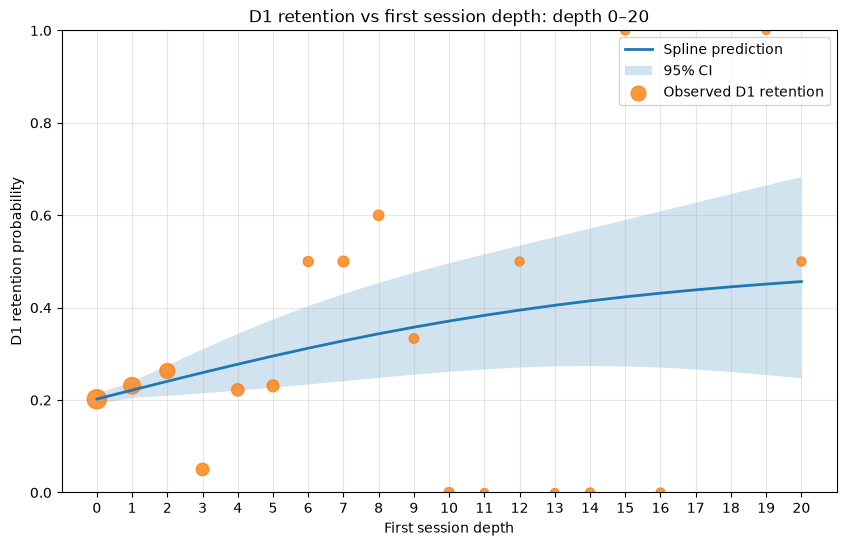

In [48]:
plt.figure(figsize=(10, 6))

mask_pred = depth_grid["first_session_depth"] <= 20
mask_obs = h3_depth["first_session_depth"] <= 20

plt.plot(
    depth_grid.loc[mask_pred, "first_session_depth"],
    depth_grid.loc[mask_pred, "predicted_d1"],
    linewidth=2,
    label="Spline prediction"
)

plt.fill_between(
    depth_grid.loc[mask_pred, "first_session_depth"],
    depth_grid.loc[mask_pred, "ci_lower"],
    depth_grid.loc[mask_pred, "ci_upper"],
    alpha=0.2,
    label="95% CI"
)

plt.scatter(
    h3_depth.loc[mask_obs, "first_session_depth"],
    h3_depth.loc[mask_obs, "d1_retention"],
    s=20 + 20 * np.log1p(
        h3_depth.loc[mask_obs, "users"]
    ),
    alpha=0.8,
    label="Observed D1 retention"
)

plt.xlabel("First session depth")
plt.ylabel("D1 retention probability")
plt.title("D1 retention vs first session depth: depth 0–20")

plt.xticks(range(0, 21))
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

First session depth действительно связан с D1 retention, тест показал, что в среднем пользователи с большим числом сессий имеют более высокую вероятность D1 Retention, однако величина эффекта невелика и составляет примерно 0.27.

# H4 - Same-day return и D1 retention

Проверим, действительно ли пользователи, которые в день первого использования возвращаются в отдельную игровую сессию в тот же день, имеют более высокий D1 retention по сравнению с остальными пользователями. Использован односторонний z-тест на пропорции, так как случайная величина `is_d1_retained` бинарная.

- H₀: p_same-day-return ≤ p_no-same-day-return

- H₁: p_same-day-return > p_no-same-day-return

- α = 0.05

In [49]:
h4_data = mart[mart["is_d1_observable"].eq(True)]

len(h4_data)

6000

In [50]:
h4_groups = (
    h4_data
    .groupby("same_day_return", as_index=False)
    .agg(
        users=("user_pseudo_id", "size"),
        d1_retained_users=("is_d1_retained", "sum")
    )
)

h4_groups["d1_retention"] = (h4_groups["d1_retained_users"] / h4_groups["users"])

h4_groups

,same_day_return,users,d1_retained_users,d1_retention
0,False,1916,286,0.149269
1,True,4084,954,0.233595


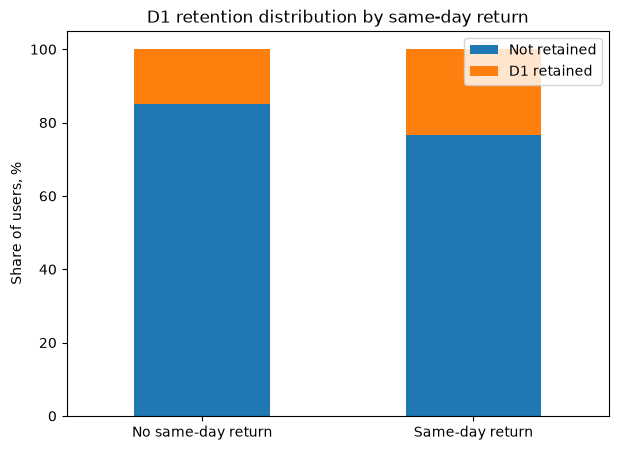

In [139]:
h4_distribution = (
    pd.crosstab(
        h4_data["same_day_return"],
        h4_data["is_d1_retained"],
        normalize="index"
    ) * 100
)

h4_distribution = h4_distribution.rename(
    index={
        False: "No same-day return",
        True: "Same-day return"
    },
    columns={
        False: "Not retained",
        True: "D1 retained"
    }
)

h4_distribution[
    ["Not retained", "D1 retained"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.ylabel("Share of users, %")
plt.xlabel("")
plt.title("D1 retention distribution by same-day return")
plt.xticks(rotation=0)
plt.legend(title="")
plt.show()

In [51]:
return_group = h4_groups.loc[
    h4_groups["same_day_return"].eq(True)
].iloc[0]

no_return_group = h4_groups.loc[
    h4_groups["same_day_return"].eq(False)
].iloc[0]

return_users = int(return_group["users"])
return_retained = int(return_group["d1_retained_users"])

no_return_users = int(no_return_group["users"])
no_return_retained = int(no_return_group["d1_retained_users"])

In [104]:
count = np.array([
    return_retained,
    no_return_retained,
])

nobs = np.array([
    return_users,
    no_return_users,
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="larger",
)

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.3e}")

z-statistic: 7.521
p-value: 2.724e-14


In [53]:
return_rate = return_retained / return_users

no_return_rate = no_return_retained / no_return_users

absolute_difference = return_rate - no_return_rate

relative_lift = absolute_difference / no_return_rate

risk_ratio = return_rate / no_return_rate

print(f"Same-day return D1: {return_rate:.2%}")
print(f"No same-day return D1: {no_return_rate:.2%}")
print(f"Difference: {absolute_difference * 100:.2f} п.п.")
print(f"Relative lift: {relative_lift:.2%}")
print(f"Risk ratio: {risk_ratio:.3f}")

Same-day return D1: 23.36%
No same-day return D1: 14.93%
Difference: 8.43 п.п.
Relative lift: 56.49%
Risk ratio: 1.565


In [54]:
ci_low, ci_high = confint_proportions_2indep(
    count1=return_retained,
    nobs1=return_users,
    count2=no_return_retained,
    nobs2=no_return_users,
    method="newcomb",
    compare="diff",
    alpha=0.05,
)

print(f"95% CI: [{ci_low * 100:.2f}; {ci_high * 100:.2f}] п.п.")

95% CI: [6.34; 10.45] п.п.


Доверительный интервал располагается правее 0, z-тест на уровне значимости 0.05 отвергает H₀, следовательно D1 retention у пользователей, для которых Same-day return = true, статистически значимо отклоняется от ожидаемого значения при верной нулевой гипотезе в большую сторону.

same-day return связан с существенно более высоким D1 retention

# H5 - Early engagement и IAP

Проверим, правда ли, что более высокая вовлеченность пользователя на раннем этапе положительно коррелирует с вероятностью последующей внутренней покупки. 
В качестве признаков раннего engagement, по которым будем осуществлять проверку рассматриваются:

- activation после первого наблюдаемого результата;

- same-day return;

- first session depth.

IAP является редким событием: покупку совершили 22 пользователя, поэтому для бинарных признаков используется точный критерий Фишера. Для `first session depth` - критерий Манна-Уитни.

- H₀: более высокий engagement не связан с большей вероятностью IAP.

- H₁: более высокий engagement связан с большей вероятностью IAP.

- α = 0.05

## Проверим связь `is_activated` с событием IAP

In [ ]:
h5_activation = mart[mart["is_activated"].notna()]

h5_activation.groupby("is_activated").agg(users=("user_pseudo_id", "size"),iap_users=("has_iap", "sum"))

,users,iap_users
is_activated,,
False,802,1
True,3071,16


Построим сводную таблицу

In [57]:
activated_iap = (h5_activation["is_activated"].eq(True) & h5_activation["has_iap"]).sum()

activated_no_iap = (h5_activation["is_activated"].eq(True) & ~h5_activation["has_iap"]).sum()

non_activated_iap = (h5_activation["is_activated"].eq(False) & h5_activation["has_iap"]).sum()

non_activated_no_iap = (h5_activation["is_activated"].eq(False) & ~h5_activation["has_iap"]).sum()

activation_table = np.array([
    [activated_iap, activated_no_iap],
    [non_activated_iap, non_activated_no_iap]
])

activation_table

array([[  16, 3055],
       [   1,  801]])

In [81]:
activated_iap_rate = activated_iap / (activated_iap + activated_no_iap)

non_activated_iap_rate = non_activated_iap / (non_activated_iap + non_activated_no_iap)

print(f"Activated IAP rate: {activated_iap_rate:.3%}")
print(f"Non-activated IAP rate: {non_activated_iap_rate:.3%}")
print(f"Rate ratio: {activated_iap_rate / non_activated_iap_rate:.3}")

Activated IAP rate: 0.521%
Non-activated IAP rate: 0.125%
Rate ratio: 4.18


Посчитаем MDE, чтобы учесть особенности объема выборки

In [85]:
def fisher_power(n1, n0, p1, p0, alpha=.05):
    m1 = int(binom.ppf(1 - 1e-12, n1, p1))
    m0 = int(binom.ppf(1 - 1e-12, n0, p0))

    return sum(
        binom.pmf(x1, n1, p1) * binom.pmf(x0, n0, p0)
        for x1 in range(m1 + 1)
        for x0 in range(m0 + 1)
        if fisher_exact(
            [[x1, n1 - x1], [x0, n0 - x0]],
            alternative="greater"
        )[1] <= alpha
    )

def fisher_mde(n1, n0, p0, alpha=.05, power=.8):
    p1 = brentq(
        lambda p: fisher_power(n1, n0, p, p0, alpha) - power,
        p0 + 1e-9, .05
    )

    return {
        "baseline_rate": p0,
        "detectable_rate": p1,
        "mde_absolute": p1 - p0,
        "relative_effect": p1 / p0
    }

activation_mde = fisher_mde(3071, 802, 1 / 802)
activation_power = fisher_power(3071, 802, 16 / 3071, 1 / 802, 0.05)

activation_mde, activation_power

({'baseline_rate': 0.0012468827930174563,
  'detectable_rate': 0.008565562638953143,
  'mde_absolute': 0.007318679845935686,
  'relative_effect': 6.86958123644042},
 np.float64(0.3671760382880967))

Применим Критерий Фишера

In [97]:
activation_or, activation_p = fisher_exact(
    activation_table,
    alternative="greater"
)

print(f"Odds ratio: {activation_or:.3f}")
print(f"p-value: {activation_p:.3}")

Odds ratio: 4.195
p-value: 0.105


p-value не позволяет отвергнуть нулевую гипотезу при текущем уровне значимости, однако оценка MDE и реального rate ratio показала, что для того, чтобы с 80% вероятность задетектить разницу у нас недостаточно наблюдений, сейчас мощность теста составляет примерно 36% вместо 80%:

- наблюдаемая разница: 0.521% - 0.125% = 0.396 п.п.
- MDE: 0.732 п.п.
- наблюдаемый rate ratio: ~ 4.18
- 80% power: нужен ~ 6.87

Установим, какой объем выборки позволил бы отследить эффект на уровне значимости 0.05 и мощностью 80%:

In [92]:
k_active = brentq(lambda k: fisher_power( round(3071 * k), round(802 * k), 16 / 3071, 1 / 802) - 0.8, 1, 10)

In [93]:
n_active= round(3071 * k_active)
n_non_active = round(802 * k_active)

n_active, n_non_active, n_active + n_non_active, round(k_active, 2)

(6893, 1800, 8693, 2.24)

Чтобы отследить эффект необходимо увеличить объем выборки примерно в 2.24 раза.

## Проверим связь `same_day_return` c IAP

In [60]:
same_day_iap = (mart["same_day_return"] & mart["has_iap"]).sum()

same_day_no_iap = (mart["same_day_return"] & ~mart["has_iap"]).sum()

no_same_day_iap = (~mart["same_day_return"] & mart["has_iap"]).sum()

no_same_day_no_iap = ( ~mart["same_day_return"] & ~mart["has_iap"]).sum()

same_day_table = np.array([
    [same_day_iap, same_day_no_iap],
    [no_same_day_iap, no_same_day_no_iap],
])

same_day_table

array([[  18, 4128],
       [   4, 1918]])

In [78]:
same_day_iap_rate = same_day_iap / (same_day_iap + same_day_no_iap)

no_same_day_iap_rate = no_same_day_iap / (no_same_day_iap + no_same_day_no_iap)

print(f"Same-day return IAP rate: {same_day_iap_rate:.3%}")
print(f"No same-day return IAP rate: {no_same_day_iap_rate:.3%}")
print(f"Relative effect: {same_day_iap_rate / no_same_day_iap_rate:.3}")

Same-day return IAP rate: 0.434%
No same-day return IAP rate: 0.208%
Relative effect: 2.09


In [86]:
same_day_mde = fisher_mde(4146, 1922, 4 / 1922)
same_day_power = fisher_power(4146, 1922, 18 / 4146, 4 / 1922, 0.05)

same_day_mde, same_day_power

({'baseline_rate': 0.002081165452653486,
  'detectable_rate': 0.007013441659741326,
  'mde_absolute': 0.00493227620708784,
  'relative_effect': 3.369958717505707},
 np.float64(0.3137619960421824))

In [96]:
same_day_or, same_day_p = fisher_exact(
    same_day_table,
    alternative="greater"
)
print(f"Odds ratio: {same_day_or:.3f}")
print(f"p-value: {same_day_p:.3}")

Odds ratio: 2.091
p-value: 0.126


p-value не позволяет отвергнуть нулевую гипотезу при текущем уровне значимости, однако оценка MDE и реального rate ratio показала, что для того, чтобы с 80% вероятность задетектить разницу у нас недостаточно наблюдений, мощность теста составила примерно 31% вмсто желаемых 80%:

- наблюдаемая разница: 0.434% - 0.208% = 0.226 п.п.
- MDE: 0.493 п.п.
- наблюдаемый rate ratio: ~ 2.09
- 80% power: нужен ~ 3.37×

Проверим, какой объем выборки необходим для повышения чувствительности до той степени, которой будет достаточно для повышения вероятности отследить эффект до 80%

In [87]:
k = brentq(lambda k: fisher_power( round(4146 * k), round(1922 * k), 18 / 4146, 4 / 1922) - 0.8, 1, 10)

In [91]:
n_same_day= round(4146 * k)
n_non_same_day = round(1922 * k)

n_same_day, n_non_same_day, n_same_day + n_non_same_day, round(k, 2)

(13400, 6212, 19612, 3.23)

Для того, чтобы была возможность провести тест мощности 80%, нужно увеличить объем выборки примерно в 3.23 раза

## Проверим связь `first_session_depth` c IAP

In [63]:
iap_depth = mart.loc[mart["has_iap"], "first_session_depth"]

no_iap_depth = mart.loc[~mart["has_iap"],"first_session_depth"]

len(iap_depth),len(no_iap_depth), iap_depth.median(), no_iap_depth.median(), iap_depth.mean(), no_iap_depth.mean()

(22,
 6046,
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.2727272727272727),
 np.float64(0.2532252729077076))

Применим односторонний тест Манна-Уитни

In [105]:
depth_u, depth_p = mannwhitneyu(
    iap_depth,
    no_iap_depth,
    alternative="greater",
    method="asymptotic"
)

depth_rank_biserial = (2 * depth_u / (len(iap_depth) * len(no_iap_depth)) - 1)

if depth_p < 0.05:
    print("Reject null hypothesis: IAP users have greater first session depth than non-IAP users.")
else:
    print("Fail to reject null hypothesis: No significant difference in first session depth between IAP and non-IAP users.")

print(f"U-statistic: {depth_u:.0f}")
print(f"p-value: {depth_p:.3}")
print(f"Rank-biserial correlation: {depth_rank_biserial:.3f}")

Fail to reject null hypothesis: No significant difference in first session depth between IAP and non-IAP users.
U-statistic: 65178
p-value: 0.615
Rank-biserial correlation: -0.020


## Проверка вклада признаков с учетом поправки в вероятность события IAP 

Использована поправка на множественное сравнение Холма

In [65]:
h5_tests = pd.DataFrame({
    "engagement_metric": [
        "Activation",
        "Same-day return",
        "First session depth"
    ],
    "p_value": [
        activation_p,
        same_day_p,
        depth_p
    ]
})

reject, p_adjusted, _, _ = multipletests(
    h5_tests["p_value"],
    alpha=0.05,
    method="holm"
)

h5_tests["p_value_holm"] = p_adjusted
h5_tests["significant_holm"] = reject

h5_tests

,engagement_metric,p_value,p_value_holm,significant_holm
0,Activation,0.104803,0.314409,False
1,Same-day return,0.126279,0.314409,False
2,First session depth,0.615378,0.615378,False


Рассчитаем текущую мощность:

In [106]:
alpha_corr = 0.05 / len(h5_tests)

activation_power_corr = fisher_power( 3071, 802, 16 / 3071, 1 / 802, alpha=alpha_corr)

same_day_power_corr = fisher_power(4146, 1922, 18 / 4146, 4 / 1922, alpha=alpha_corr)

activation_power_corr, same_day_power_corr

(np.float64(0.12992531104088986), np.float64(0.14707922954322838))

Видно, что сейчас мощность теста, с учетом консервативной поравки Бонферрони, менее 15%

In [108]:
k_corr_active = brentq(lambda k: fisher_power( round(3071 * k), round(802 * k), 16 / 3071, 1 / 802, alpha=alpha_corr) - 0.8, 1, 10)

In [107]:
k_corr_same_day = brentq(lambda k: fisher_power( round(4146 * k), round(1922 * k), 18 / 4146, 4 / 1922, alpha=alpha_corr) - 0.8, 1, 10)

In [109]:
n_active= round(3071 * k_corr_active)
n_non_active = round(802 * k_corr_active)
n_same_day= round(4146 * k_corr_same_day)
n_non_same_day = round(1922 * k_corr_same_day)

n_active, n_non_active, n_active + n_non_active, round(k_corr_active, 2), n_same_day, n_non_same_day, n_same_day + n_non_same_day, round(k_corr_same_day, 2)

(9488, 2478, 11966, 3.09, 18599, 8622, 27221, 4.49)

Анализ позволяет заключить, что для каких-либо подкрепленных выводов необходимо увеличить объем выборки примерно в три раза в случае с оценкой влияния `is_active` и примерно в 4.5 раза в случае с `same_day_return`

Построим доверительный интервал для разности долей и шанса на появление события IAP:

In [129]:
def effect_ci(table):
    a, b = table[0]
    c, d = table[1]

    diff = a / (a + b) - c / (c + d)
    diff_ci = confint_proportions_2indep(
        a, a + b, c, c + d,
        method="newcomb", compare="diff"
    )

    OR = odds_ratio(table, kind="conditional")
    or_ci = OR.confidence_interval()

    return pd.Series({
        "difference_pp": diff * 100,
        "diff_ci_low": diff_ci[0] * 100,
        "diff_ci_high": diff_ci[1] * 100,
        "OR": OR.statistic,
        "OR_ci_low": or_ci.low,
        "OR_ci_high": or_ci.high
    })

In [130]:
ci_results = pd.DataFrame({
    "Activation": effect_ci(activation_table),
    "Same-day return": effect_ci(same_day_table),
}).T

ci_results

,difference_pp,diff_ci_low,diff_ci_high,OR,OR_ci_low,OR_ci_high
Activation,0.396315,-0.215502,0.735887,4.194107,0.649671,176.138544
Same-day return,0.226037,-0.136639,0.507509,2.090627,0.687404,8.504081


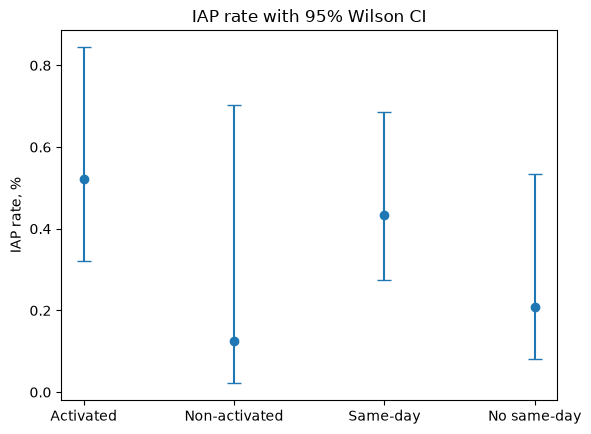

In [132]:
s = np.r_[activation_table[:, 0], same_day_table[:, 0]]
n = np.r_[activation_table.sum(1), same_day_table.sum(1)]
p = s / n

low, high = sm.stats.proportion_confint(s, n, method="wilson")

plt.errorbar(
    ["Activated", "Non-activated", "Same-day", "No same-day"],
    p * 100,
    yerr=[(p - low) * 100, (high - p) * 100],
    fmt="o", capsize=5
)

plt.ylabel("IAP rate, %")
plt.title("IAP rate with 95% Wilson CI")
plt.show()

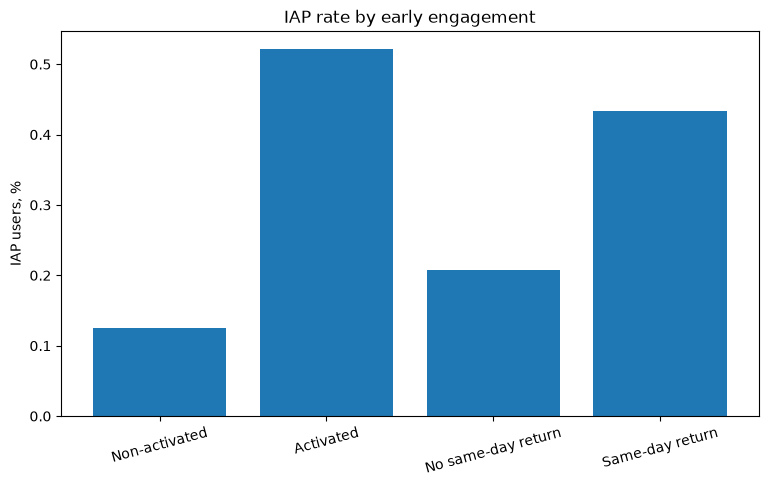

In [140]:
h5_iap_rates = pd.DataFrame({
    "group": [
        "Non-activated",
        "Activated",
        "No same-day return",
        "Same-day return"
    ],
    "iap_rate": [
        non_activated_iap_rate * 100,
        activated_iap_rate * 100,
        no_same_day_iap_rate * 100,
        same_day_iap_rate * 100
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    h5_iap_rates["group"],
    h5_iap_rates["iap_rate"]
)

plt.ylabel("IAP users, %")
plt.title("IAP rate by early engagement")
plt.xticks(rotation=15)

plt.show()

Статистически значимой связи между рассмотренными признаками ранней вовлечённости и фактом совершения IAP обнаружено не было, данный факт обусловлен малым объемом выборки, который не обеспечивает необходимую чувствительность тестам, это же подтверждают очень широкие интервалы, в связи с чем нельзя делать выводы о влиянии признаков ранней вовлеченности на наступление события IAP. 

Тем не менее можно заключить следующее:

- Для `activation` и `same_day_return` наблюдаемые odds ratio превышают единицу, но изменения не достаточны для того, чтобы отвергнуть нулевую гипотезу на уровне значимости 0.05.

- Для `first_session_depth` не обнаружено свидетельств того, что пользователи с IAP систематически имеют более высокую глубину первой сессии (Mann–Whitney p = 0.615,rank-biserial correlation = -0.020). Заметен слабый обраный эффект.

# H6 - Дополнительные ходы

Проверим, влияет ли столкновение пользователя с ограничением доступных дополнительных ходов на наличие событий rewarded-рекламы и покупку пакетов `extra_steps`.

Рассматриваются два исхода:

- `has_ad_reward`;
- `has_extra_steps_purchase`.

Гипотеза исследовательская и заранее не задаёт направление связи, используются двусторонние тесты.

- H₀: наличие `no_more_extra_steps` не связано с рассматриваемым событием.
- H₁: между событиями существует связь.
- α = 0.05.

In [111]:
h6_summary = (
    mart
    .groupby("has_no_more_extra_steps", as_index=False)
    .agg(
        users=("user_pseudo_id", "size"),
        ad_reward_users=("has_ad_reward", "sum"),
        extra_steps_purchase_users=("has_extra_steps_purchase", "sum"),
        used_extra_steps_users=("has_used_extra_steps", "sum")
    )
)

In [112]:
h6_summary["ad_reward_rate"] = h6_summary["ad_reward_users"] / h6_summary["users"]

h6_summary["extra_steps_purchase_rate"] = h6_summary["extra_steps_purchase_users"] / h6_summary["users"]

h6_summary["used_extra_steps_rate"] = h6_summary["used_extra_steps_users"] / h6_summary["users"]

h6_summary

,has_no_more_extra_steps,users,ad_reward_users,extra_steps_purchase_users,used_extra_steps_users,ad_reward_rate,extra_steps_purchase_rate,used_extra_steps_rate
0,False,5245,12,2,564,0.002288,0.000381,0.107531
1,True,823,161,3,693,0.195626,0.003645,0.842041


## Связь no_more_extra_steps с rewarded ad

In [114]:
no_more_ad = (mart["has_no_more_extra_steps"] & mart["has_ad_reward"]).sum()

no_more_no_ad = (mart["has_no_more_extra_steps"] & ~mart["has_ad_reward"]).sum()

no_no_more_ad = (~mart["has_no_more_extra_steps"] & mart["has_ad_reward"]).sum()

no_no_more_no_ad = ( ~mart["has_no_more_extra_steps"] & ~mart["has_ad_reward"]).sum()

ad_table = np.array([
    [no_more_ad, no_more_no_ad],
    [no_no_more_ad, no_no_more_no_ad],
])

ad_table

array([[ 161,  662],
       [  12, 5233]])

In [115]:
ad_rate_no_more = no_more_ad / (no_more_ad + no_more_no_ad)

ad_rate_without = no_no_more_ad / (no_no_more_ad + no_no_more_no_ad)

print(f"Ad reward rate with no_more_extra_steps: {ad_rate_no_more:.2%}")
print(f"Ad reward rate without no_more_extra_steps: {ad_rate_without:.2%}")

Ad reward rate with no_more_extra_steps: 19.56%
Ad reward rate without no_more_extra_steps: 0.23%


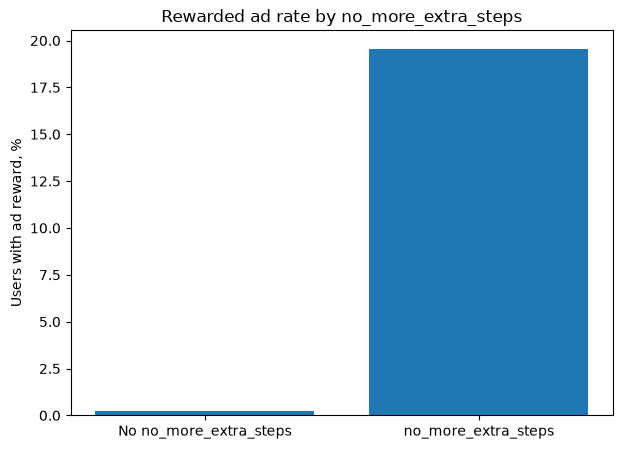

In [141]:
plt.figure(figsize=(7, 5))

plt.bar(
    [
        "No no_more_extra_steps",
        "no_more_extra_steps"
    ],
    [
        ad_rate_without * 100,
        ad_rate_no_more * 100
    ]
)

plt.ylabel("Users with ad reward, %")
plt.title("Rewarded ad rate by no_more_extra_steps")

plt.show()

In [118]:
ad_or, ad_p = fisher_exact(
    ad_table,
    alternative="two-sided"
)
print(f"Odds ratio: {ad_or:.3f}")
print(f"p-value: {ad_p:.3e}")

Odds ratio: 106.057
p-value: 2.200e-129


## Связь no_more_extra_steps с purchase extra steps

In [119]:
no_more_purchase = (mart["has_no_more_extra_steps"] & mart["has_extra_steps_purchase"]).sum()

no_more_no_purchase = (mart["has_no_more_extra_steps"] & ~mart["has_extra_steps_purchase"]).sum()

no_no_more_purchase = (~mart["has_no_more_extra_steps"] & mart["has_extra_steps_purchase"]).sum()

no_no_more_no_purchase = (~mart["has_no_more_extra_steps"] & ~mart["has_extra_steps_purchase"]).sum()

purchase_table = np.array([
    [no_more_purchase, no_more_no_purchase],
    [no_no_more_purchase, no_no_more_no_purchase],
])

purchase_table

array([[   3,  820],
       [   2, 5243]])

In [120]:
purchase_rate_no_more = no_more_purchase / (no_more_purchase + no_more_no_purchase)


purchase_rate_without = no_no_more_purchase / (no_no_more_purchase + no_no_more_no_purchase)

print(f"Extra steps purchase rate with no_more_extra_steps: {purchase_rate_no_more:.3%}")

print(f"Extra steps purchase rate without no_more_extra_steps: {purchase_rate_without:.3%}")

Extra steps purchase rate with no_more_extra_steps: 0.365%
Extra steps purchase rate without no_more_extra_steps: 0.038%


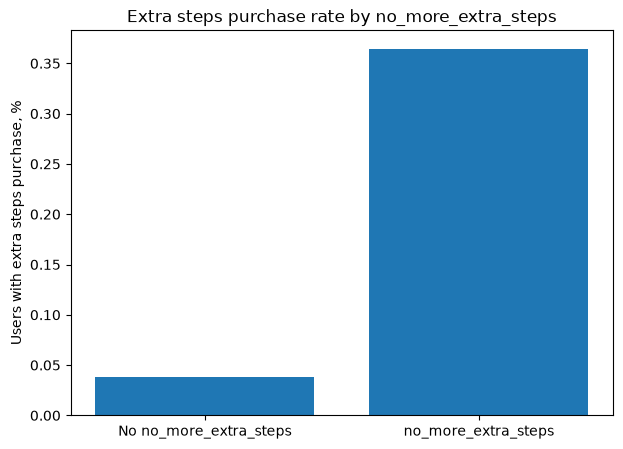

In [142]:
plt.figure(figsize=(7, 5))

plt.bar(
    [
        "No no_more_extra_steps",
        "no_more_extra_steps"
    ],
    [
        purchase_rate_without * 100,
        purchase_rate_no_more * 100
    ]
)

plt.ylabel("Users with extra steps purchase, %")
plt.title("Extra steps purchase rate by no_more_extra_steps")

plt.show()

In [122]:
purchase_or, purchase_p = fisher_exact(
    purchase_table,
    alternative="two-sided"
)

print(f"Odds ratio: {purchase_or:.3f}")
print(f"p-value: {purchase_p:.3}")

Odds ratio: 9.591
p-value: 0.0201


## Оценка вклада с учетом поправки Холма

In [123]:
h6_tests = pd.DataFrame({
    "outcome": [
        "Ad reward",
        "Extra steps purchase",
    ],
    "p_value": [
        ad_p,
        purchase_p,
    ],
})

reject, p_adjusted, _, _ = multipletests(
    h6_tests["p_value"],
    alpha=0.05,
    method="holm"
)

h6_tests["p_value_holm"] = p_adjusted
h6_tests["significant_holm"] = reject

h6_tests

,outcome,p_value,p_value_holm,significant_holm
0,Ad reward,2.199930e-129,4.399859e-129,True
1,Extra steps purchase,2.009956e-02,2.009956e-02,True


Посмотрим на доверительный интервал:

In [134]:
ci_results = pd.DataFrame({
    "Rewarded ad": effect_ci(ad_table),
    "Extra steps purchase": effect_ci(purchase_table)
}).T

ci_results

,difference_pp,diff_ci_low,diff_ci_high,OR,OR_ci_low,OR_ci_high
Rewarded ad,19.333787,16.762002,22.184401,105.911765,58.570433,210.432997
Extra steps purchase,0.326388,0.065640,1.028616,9.584581,1.096225,114.914979


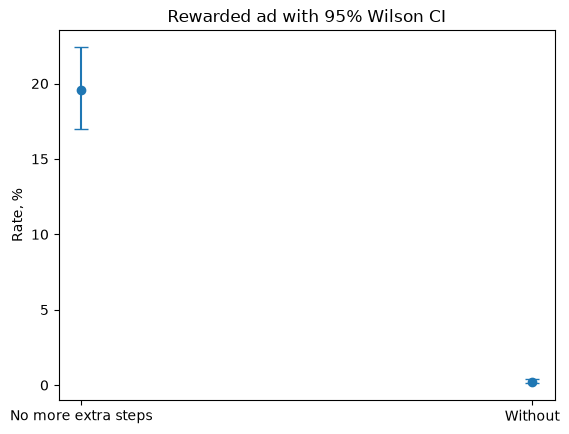

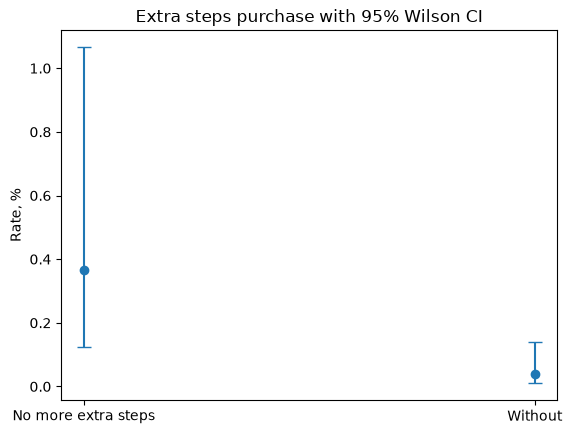

In [136]:
for table, title in [
    (ad_table, "Rewarded ad"),
    (purchase_table, "Extra steps purchase")
]:
    s, n = table[:, 0], table.sum(1)
    p = s / n
    low, high = sm.stats.proportion_confint(s, n, method="wilson")

    plt.figure()
    plt.errorbar(
        ["No more extra steps", "Without"],
        p * 100,
        yerr=[(p-low)*100, (high-p)*100],
        fmt="o", capsize=5
    )
    plt.ylabel("Rate, %")
    plt.title(f"{title} with 95% Wilson CI")
    plt.show()

Проверки позволяют заключить, что пользователи, у которых встречается `no_more_extra_steps`, существенно чаще имеют как rewarded ad, так и покупку дополнительных ходов.

Rewarded ad наблюдается у 19.56% пользователей с `no_more_extra_steps` и только у 0.23% пользователей без этого события.

Покупка дополнительных ходов также наблюдается чаще среди пользователей с `no_more_extra_steps`: 0.365% против 0.038%. Однако при интерпретации стоит учитывать, что покупку `extra_steps` совершили только 5 пользователей, оценка величины связи нестабильна, что также подтверждено доверительными интервалами.